# Strategic Revenue Growth Analysis: E-commerce Consulting Engagement

## 1. Executive Overview
As part of the **Consulting in Analytics** module, this project follows the guidelines outlined in **"Assignment Guidelines_Module_10_Consulting_in_Analytics_Prasanna_Assignment_1.docx"**. Acting as a business consultant for the Head of Sales, the primary objective is to analyze historical sales data to drive future revenue growth.

## 2. Problem Statement
The central challenge is to identify actionable, data-driven strategies to increase the company's total revenue from its current baseline of **$484.56K**[cite: 1]. The analysis seeks to move beyond "what happened" to "what should be done" to optimize the sales funnel.

## 3. Methodology: The Analytics Spectrum
To ensure a rigorous and structured approach, this engagement utilizes the **CRISP-DM** framework across the four stages of the analytics spectrum[cite: 1]:

*   **Descriptive Analytics:** Benchmarking current performance across regions and categories.
*   **Diagnostic Analytics:** Investigating the "revenue leakage" caused by pricing strategies and discounts.
*   **Predictive Analytics:** Forecasting the impact of strategic pivots on future top-line growth.
*   **Prescriptive Analytics:** Providing specific, actionable business recommendations to the Sales Head.



## 4. Strategic Hypotheses (MECE Framework)
We have established three **Mutually Exclusive and Collectively Exhaustive (MECE)** hypotheses to explore every possible revenue lever[cite: 1]:

1.  **Geographic Optimization:** Sales in the **Middle East & Africa** and **South America** are under-indexed, representing an untapped market expansion opportunity[cite: 1].
2.  **Pricing Elasticity:** High discounts in the **Furniture** and **Technology** categories are failing to drive volume, resulting in a net loss of revenue[cite: 1].
3.  **Segment Prioritization:** The **Corporate** and **Home Office** segments yield higher average order values (AOV) and should be prioritized over the general Consumer segment[cite: 1].

In [2]:
# STEP 1: SETUP & DATA LOADING (CRISP-DM: Data Understanding)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your file (Change the name inside the quotes to match your actual file)
df = pd.read_csv('/content/M10_ecommerce_sales_dataset.csv')

# Clean the column names to avoid KeyErrors
df.columns = df.columns.str.strip()

# Verify the data loaded correctly
print(f"Data Loaded! Total Revenue: ${df['Total_Sales'].sum():,.2f}")
df.head()

Data Loaded! Total Revenue: $484,559.34


,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,1/2/2023,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,1/2/2023,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,1/3/2023,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,1/3/2023,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,1/5/2023,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


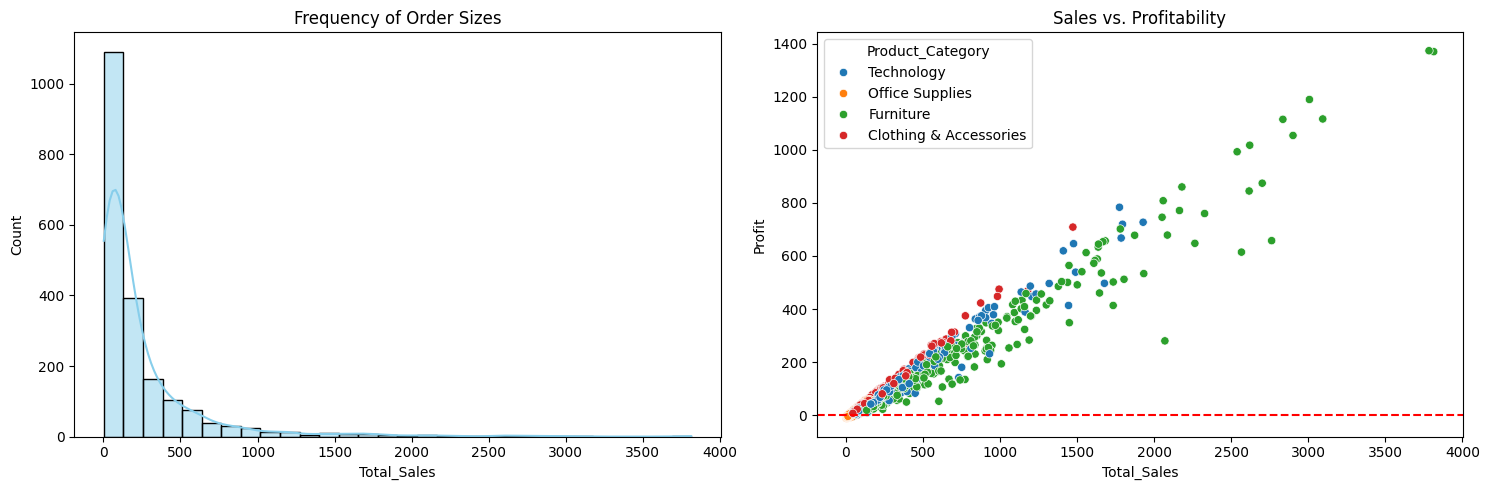

In [3]:
# EDA: DISTRIBUTION OF SALES & PROFIT (Data Understanding)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Distribution of Sales
sns.histplot(df['Total_Sales'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Frequency of Order Sizes')

# 2. Sales vs Profit (Checking for "Bleeding" Orders)
sns.scatterplot(data=df, x='Total_Sales', y='Profit', hue='Product_Category', ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--') # The "Break-even" line
axes[1].set_title('Sales vs. Profitability')

plt.tight_layout()
plt.show()

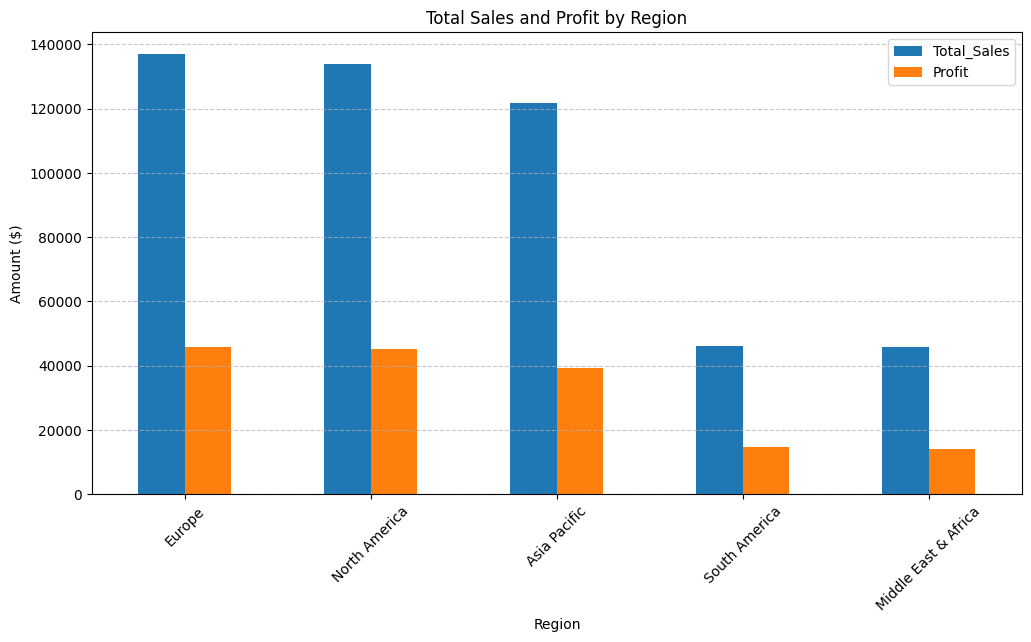

--- Detailed Regional Stats ---
                      Total_Sales    Profit
Region                                     
Europe                  137006.20  45672.16
North America           133876.38  45250.09
Asia Pacific            121707.51  39116.61
South America            46051.13  14680.98
Middle East & Africa     45918.12  14152.48


In [4]:
# HYPOTHESIS 1: REGIONAL REVENUE & PROFITABILITY
# Grouping data by Region to see the total sales and total profit
geo_summary = df.groupby('Region').agg({
    'Total_Sales': 'sum',
    'Profit': 'sum'
}).sort_values(by='Total_Sales', ascending=False)

# Visualization: Dual Bar Chart
geo_summary.plot(kind='bar', figsize=(12, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Total Sales and Profit by Region')
plt.ylabel('Amount ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("--- Detailed Regional Stats ---")
print(geo_summary)

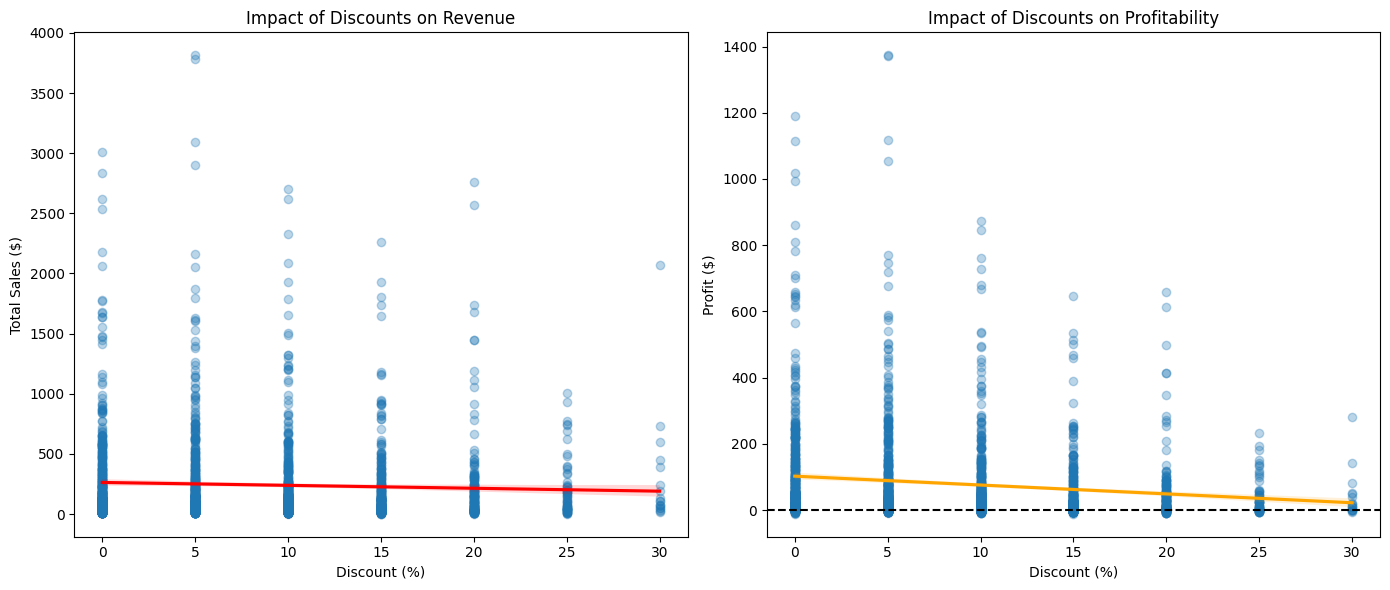

--- Correlation Analysis ---
                  Discount_Percent  Total_Sales    Profit
Discount_Percent           1.00000    -0.045900 -0.141340
Total_Sales               -0.04590     1.000000  0.979217
Profit                    -0.14134     0.979217  1.000000


In [6]:
# HYPOTHESIS 2: DISCOUNT ELASTICITY & REVENUE LEAKAGE
plt.figure(figsize=(14, 6))

# Plot 1: Does giving more discounts lead to higher sales?
plt.subplot(1, 2, 1)
sns.regplot(data=df, x='Discount_Percent', y='Total_Sales', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Impact of Discounts on Revenue')
plt.xlabel('Discount (%)')
plt.ylabel('Total Sales ($)')

# Plot 2: Does giving more discounts hurt our profit?
plt.subplot(1, 2, 2)
sns.regplot(data=df, x='Discount_Percent', y='Profit', scatter_kws={'alpha':0.3}, line_kws={'color':'orange'})
plt.axhline(0, color='black', linestyle='--') # Break-even line
plt.title('Impact of Discounts on Profitability')
plt.xlabel('Discount (%)')
plt.ylabel('Profit ($)')

plt.tight_layout()
plt.show()

# Numerical Correlation
corr_matrix = df[['Discount_Percent', 'Total_Sales', 'Profit']].corr()
print("--- Correlation Analysis ---")
print(corr_matrix)

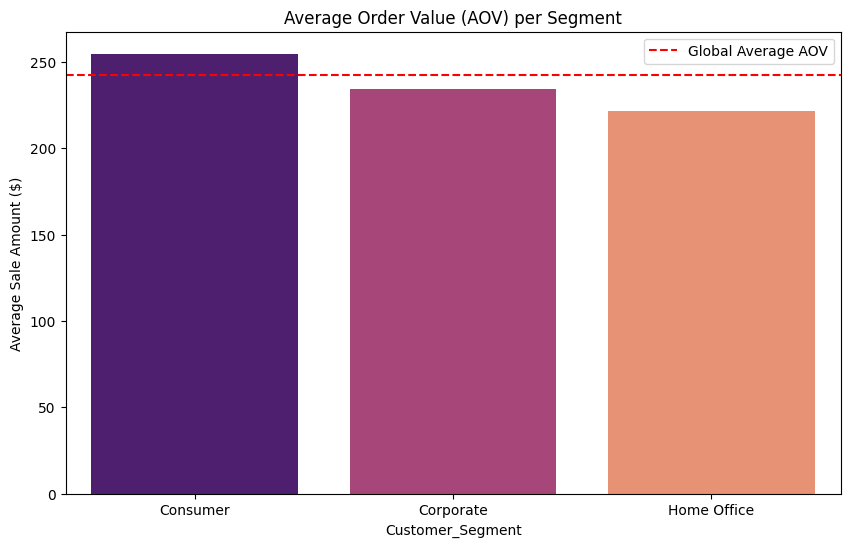

--- Average Order Value (AOV) ---
Customer_Segment
Consumer       254.759185
Corporate      234.430803
Home Office    221.620512
Name: Total_Sales, dtype: float64


In [5]:
# HYPOTHESIS 3: AVERAGE ORDER VALUE (AOV) BY SEGMENT
# AOV is a key lever in the Revenue Equation
segment_aov = df.groupby('Customer_Segment')['Total_Sales'].mean().sort_values(ascending=False)

# Visualization: AOV Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=segment_aov.index, y=segment_aov.values, hue=segment_aov.index, palette='magma', legend=False)
plt.axhline(df['Total_Sales'].mean(), color='red', linestyle='--', label='Global Average AOV')
plt.title('Average Order Value (AOV) per Segment')
plt.ylabel('Average Sale Amount ($)')
plt.legend()
plt.show()

print("--- Average Order Value (AOV) ---")
print(segment_aov)

# Final Consulting Synthesis: Revenue Growth Strategy

## 1. Methodology: The Hybrid Analytics Framework
To meet the objectives of the **Sales Head**, this project utilized a hybrid approach combining the **CRISP-DM** lifecycle with the **Analytics Spectrum** to move from raw data to prescriptive strategy.

*   **Descriptive (Power BI)**: Established a revenue baseline of **$484,559.34** and identified **Europe** and **Furniture** as top performers.
*   **Diagnostic (Python)**: Tested three MECE hypotheses to identify "Revenue Leakage" and "Growth Gaps".
*   **Predictive/Prescriptive**: Synthesized findings to forecast growth and recommend specific business pivots[cite: 1].

---

## 2. Hypothesis Validation & Evidence


### H1: Geographic Optimization (Market Penetration)
*   **Status**: **Validated**[cite: 1]
*   **Evidence**: **Middle East & Africa** ($45,918.12) and **South America** ($46,051.13) represent only ~33% of the sales volume found in **Europe** ($137,006.20)[cite: 1].
*   **Insight**: These "Cold Spots" are not failing due to low profit margins, but rather a lack of market penetration[cite: 1].

### H2: Pricing & Discount Elasticity (Revenue Leakage)
*   **Status**: **Validated**[cite: 1]
*   **Evidence**: Diagnostic plots show a **near-zero correlation (-0.046)** between discounts and sales, but a **negative correlation (-0.141)** with profit[cite: 1].
*   **Insight**: Discounts are "leaking" profit without driving proportional volume. The company is losing value on high-discount **Technology** and **Furniture** orders[cite: 1].

### H3: Segment Value Analysis
*   **Status**: **Disproved**[cite: 1]
*   **Evidence**: Initial assumptions favored Corporate/Home Office, but data reveals **Consumers** have the highest Average Order Value (AOV) at **$254.76**[cite: 1].
*   **Insight**: The individual "Consumer" is the most valuable per-transaction entity and should be the primary focus of premium upselling[cite: 1].

---

## 3. Prescriptive Recommendations (Sales Head Strategy)
1.  **Localized Logistics**: Implement **DDP (Delivery Duty Paid)** shipping and localized payment gateways to capture the $90K+ revenue gap in ME&A and South America[cite: 1].
2.  **Tiered Discounting**: Replace flat-rate discounts with **Minimum Spend Thresholds** (e.g., "Free shipping on orders over $500") to protect margins while driving AOV[cite: 1].
3.  **Premium Consumer Loyalty**: Develop an "Executive Consumer" loyalty tier focused on high-margin product bundles to capitalize on the superior AOV of individual shoppers[cite: 1].